Connected to base (Python 3.9.13)

Explore Palantir Pseudotime

In [2]:
import scanpy as sc
import pandas as pd
data = sc.read_h5ad('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Data/Complete_LARRY_dataset_adata_preprocessed_barcodes_palantir.h5ad')

plot pseudotime on umap embedding

Text(0.5, 1.0, 'Palantir Pseudotime')

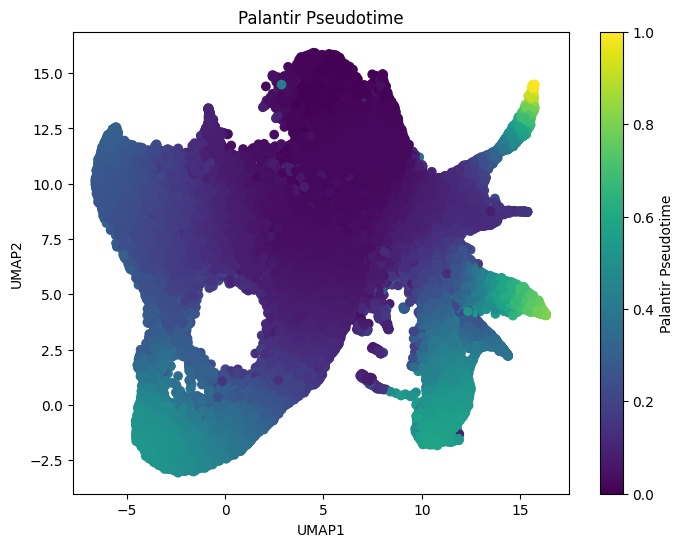

In [3]:
df = pd.DataFrame({'UMAP1': data.obsm['X_umap'][:, 0], 'UMAP2': data.obsm['X_umap'][:, 1], 
                   'state_info': data.obs['state_info'], 'palantir_pseudotime': data.obs['palantir_pseudotime']})
#seaborn scatterplot
import seaborn as sns
import matplotlib.pyplot as plt
# Create scatter plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(df["UMAP1"], df["UMAP2"], c=df["palantir_pseudotime"], cmap='viridis', alpha=1)
# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Palantir Pseudotime')
# Labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Palantir Pseudotime')

plot cells in both day 6 and terminal states on umap embedding

/tmp/ipykernel_26434/3374911204.py:41: UserWarning: 
The palette list has fewer values (8) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


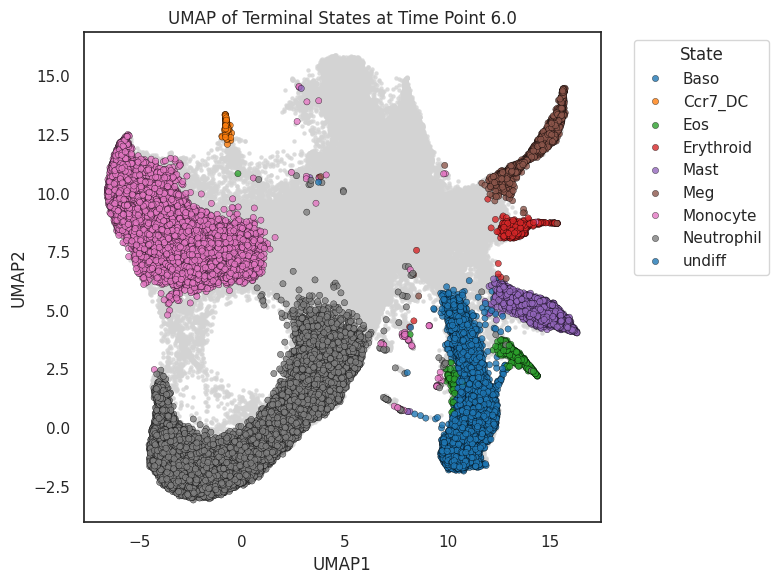

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style without grid
sns.set(style="white")  # or "ticks" for minimal axes

# Terminal states
terminal_state = ["Monocyte", "Neutrophil", "Baso", "Mast",
                  "Erythroid", "Meg", "Eos", "Ccr7_DC"]

# Create dataframe
df = pd.DataFrame({
    'UMAP1': data.obsm['X_umap'][:, 0],
    'UMAP2': data.obsm['X_umap'][:, 1], 
    'state_info': data.obs['state_info'],
    'palantir_pseudotime': data.obs['palantir_pseudotime'],
    'Time_Point': data.obs['Time_Point']
})

# Split into terminal and non-terminal at 6.0 time point
df1 = df[(df['Time_Point'] == '6.0') & (df['state_info'].isin(terminal_state))]
df2 = df[~df.index.isin(df1.index)]

# Initialize figure
plt.figure(figsize=(8, 6))

# Plot non-terminal cells in grey
sns.scatterplot(
    x='UMAP1', 
    y='UMAP2', 
    data=df2, 
    color='lightgrey', 
    alpha=0.8, 
    s=10, 
    linewidth=0
)

# Plot terminal state cells
palette = sns.color_palette("tab10", n_colors=df1["state_info"].nunique())
sns.scatterplot(
    x='UMAP1', 
    y='UMAP2', 
    hue='state_info',  
    palette=palette, 
    data=df1, 
    edgecolor="black",  
    alpha=0.8, 
    s=20,
    linewidth=0.3
)

# Remove grid
plt.grid(False)

# Customize legend and layout
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("UMAP of Terminal States at Time Point 6.0")
plt.tight_layout()
plt.show()
#plt.savefig('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Palantir/palantir_pseudotime_only_day6terminal.png', dpi = 300)

exclude cells in both day 6 and terminal states on umap embedding

Text(0.5, 1.0, 'Palantir Pseudotime without day 6 terminal state cell')

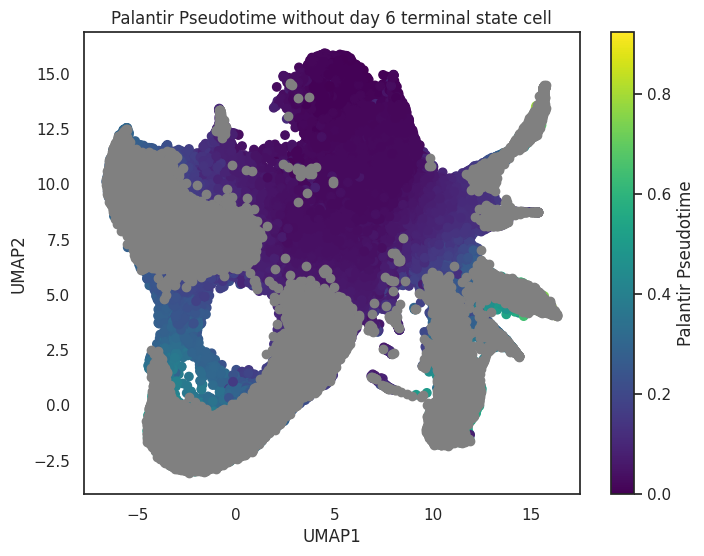

In [10]:
#if I exclude all cells in day 6 and in terminate state, what will the pseudotime be
terminal_state = ["Monocyte", "Neutrophil", "Baso", "Mast",
                  "Erythroid", "Meg", "Eos", "Ccr7_DC"]
df = pd.DataFrame({'UMAP1': data.obsm['X_umap'][:, 0], 'UMAP2': data.obsm['X_umap'][:, 1], 
                   'state_info': data.obs['state_info'], 'palantir_pseudotime': data.obs['palantir_pseudotime'],
                   'Time_Point': data.obs['Time_Point']})
df1 = df[(df['Time_Point'] == '6.0' ) & (df['state_info'].isin(terminal_state))]
df2 = df[~df.index.isin(df1.index)]
plt.figure(figsize=(8, 6))
sc = plt.scatter(df2["UMAP1"], df2["UMAP2"], c=df2["palantir_pseudotime"], cmap='viridis', alpha=1)
# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Palantir Pseudotime')
sc = plt.scatter(df1["UMAP1"], df1["UMAP2"], c='grey', alpha=1)
# Labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Palantir Pseudotime without day 6 terminal state cell')
#plt.savefig('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Palantir/palantir_pseudotime_without_day6terminal.png', dpi = 300)

plot psudotime on umap embedding with quantile

Text(0.5, 1.0, 'Palantir Pseudotime without day 6 terminal state cell, quantile 0-0.2')

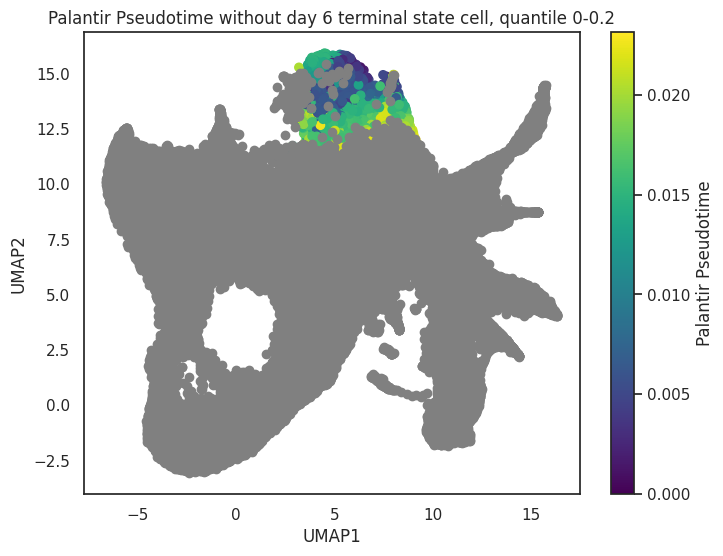

In [11]:
#if I exclude all cells in day 6 and in terminate state, what will the pseudotime be
terminal_state = ["Monocyte", "Neutrophil", "Baso", "Mast",
                  "Erythroid", "Meg", "Eos", "Ccr7_DC"]
df = pd.DataFrame({'UMAP1': data.obsm['X_umap'][:, 0], 'UMAP2': data.obsm['X_umap'][:, 1], 
                   'state_info': data.obs['state_info'], 'palantir_pseudotime': data.obs['palantir_pseudotime'],
                   'Time_Point': data.obs['Time_Point']})
df1 = df[(df['Time_Point'] == '6.0' ) & (df['state_info'].isin(terminal_state))]
df2 = df[~df.index.isin(df1.index)]
import numpy as np
# Compute the 20th percentile cutoff
lower_bound = np.quantile(df2['palantir_pseudotime'], 0.0)  # 0th percentile (min value)
upper_bound = np.quantile(df2['palantir_pseudotime'], 0.2)  # 20th percentile
# Subset data
df2_1 = df2[(df2['palantir_pseudotime'] >= lower_bound) & (df2['palantir_pseudotime'] <= upper_bound)]
df2_2 = df2[(df2['palantir_pseudotime'] > upper_bound)]
plt.figure(figsize=(8, 6))
sc = plt.scatter(df2_1["UMAP1"], df2_1["UMAP2"], c=df2_1["palantir_pseudotime"], cmap='viridis', alpha=1)
# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Palantir Pseudotime')
sc = plt.scatter(df1["UMAP1"], df1["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_2["UMAP1"], df2_2["UMAP2"], c='grey', alpha=1)
# Labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Palantir Pseudotime without day 6 terminal state cell, quantile 0-0.2')
#plt.savefig('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Palantir/palantir_pseudotime_without_day6terminal_quant0_20.png', dpi = 300)


if I exclude all cells in day 6 and in terminate state, what will the pseudotime be

Text(0.5, 1.0, 'Palantir Pseudotime without day 6 terminal state cell, quantile 0.2-0.4')

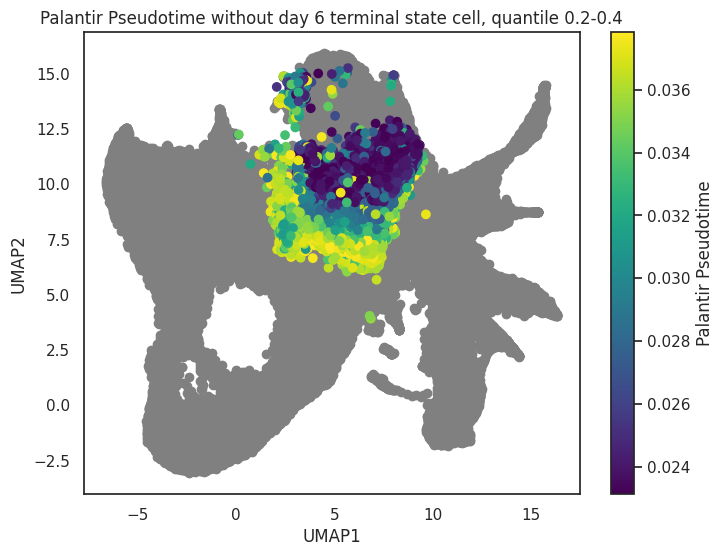

In [12]:
terminal_state = ["Monocyte", "Neutrophil", "Baso", "Mast",
                  "Erythroid", "Meg", "Eos", "Ccr7_DC"]
df = pd.DataFrame({'UMAP1': data.obsm['X_umap'][:, 0], 'UMAP2': data.obsm['X_umap'][:, 1], 
                   'state_info': data.obs['state_info'], 'palantir_pseudotime': data.obs['palantir_pseudotime'],
                   'Time_Point': data.obs['Time_Point']})
df1 = df[(df['Time_Point'] == '6.0' ) & (df['state_info'].isin(terminal_state))]
df2 = df[~df.index.isin(df1.index)]
import numpy as np
# Compute the 20th percentile cutoff
lower_bound = np.quantile(df2['palantir_pseudotime'], 0.2)  # 0th percentile (min value)
upper_bound = np.quantile(df2['palantir_pseudotime'], 0.4)  # 20th percentile
# Subset data
df2_1 = df2[(df2['palantir_pseudotime'] >= lower_bound) & (df2['palantir_pseudotime'] <= upper_bound)]
df2_2 = df2[~df2.index.isin(df2_1.index)]
plt.figure(figsize=(8, 6))
sc = plt.scatter(df1["UMAP1"], df1["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_2["UMAP1"], df2_2["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_1["UMAP1"], df2_1["UMAP2"], c=df2_1["palantir_pseudotime"], cmap='viridis', alpha=1)
# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Palantir Pseudotime')
# Labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Palantir Pseudotime without day 6 terminal state cell, quantile 0.2-0.4')
#plt.savefig('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Palantir/palantir_pseudotime_without_day6terminal_quant20_40.png', dpi = 300)


if I exclude all cells in day 6 and in terminate state, what will the pseudotime be

Text(0.5, 1.0, 'Palantir Pseudotime without day 6 terminal state cell, quantile 0.4-0.6')

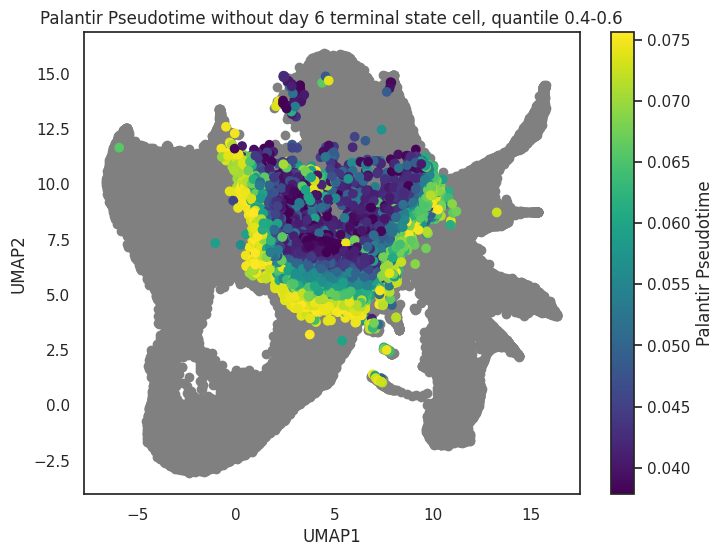

In [13]:
terminal_state = ["Monocyte", "Neutrophil", "Baso", "Mast",
                  "Erythroid", "Meg", "Eos", "Ccr7_DC"]
df = pd.DataFrame({'UMAP1': data.obsm['X_umap'][:, 0], 'UMAP2': data.obsm['X_umap'][:, 1], 
                   'state_info': data.obs['state_info'], 'palantir_pseudotime': data.obs['palantir_pseudotime'],
                   'Time_Point': data.obs['Time_Point']})
df1 = df[(df['Time_Point'] == '6.0' ) & (df['state_info'].isin(terminal_state))]
df2 = df[~df.index.isin(df1.index)]
import numpy as np
# Compute the 20th percentile cutoff
lower_bound = np.quantile(df2['palantir_pseudotime'], 0.4)  # 0th percentile (min value)
upper_bound = np.quantile(df2['palantir_pseudotime'], 0.6)  # 20th percentile
# Subset data
df2_1 = df2[(df2['palantir_pseudotime'] >= lower_bound) & (df2['palantir_pseudotime'] <= upper_bound)]
df2_2 = df2[~df2.index.isin(df2_1.index)]
plt.figure(figsize=(8, 6))
sc = plt.scatter(df1["UMAP1"], df1["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_2["UMAP1"], df2_2["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_1["UMAP1"], df2_1["UMAP2"], c=df2_1["palantir_pseudotime"], cmap='viridis', alpha=1)
# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Palantir Pseudotime')
# Labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Palantir Pseudotime without day 6 terminal state cell, quantile 0.4-0.6')
#plt.savefig('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Palantir/palantir_pseudotime_without_day6terminal_quant40_60.png', dpi = 300)



if I exclude all cells in day 6 and in terminate state, what will the pseudotime be

Text(0.5, 1.0, 'Palantir Pseudotime without day 6 terminal state cell, quantile 0.6-0.8')

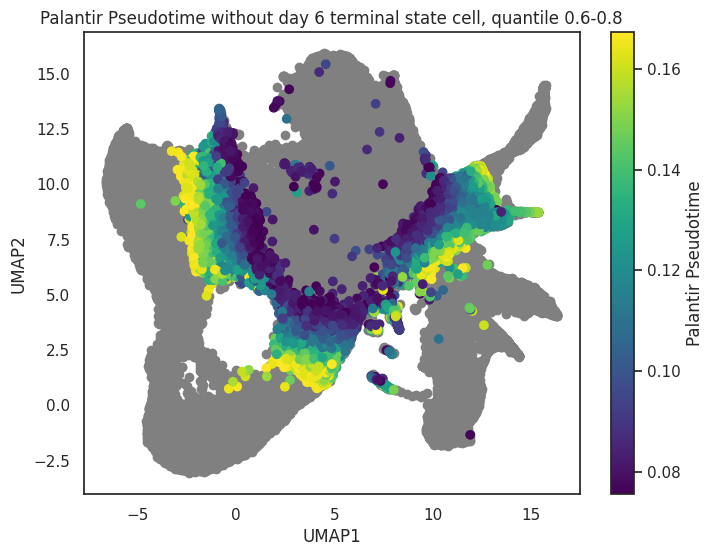

In [14]:
terminal_state = ["Monocyte", "Neutrophil", "Baso", "Mast",
                  "Erythroid", "Meg", "Eos", "Ccr7_DC"]
df = pd.DataFrame({'UMAP1': data.obsm['X_umap'][:, 0], 'UMAP2': data.obsm['X_umap'][:, 1], 
                   'state_info': data.obs['state_info'], 'palantir_pseudotime': data.obs['palantir_pseudotime'],
                   'Time_Point': data.obs['Time_Point']})
df1 = df[(df['Time_Point'] == '6.0' ) & (df['state_info'].isin(terminal_state))]
df2 = df[~df.index.isin(df1.index)]
import numpy as np
# Compute the 20th percentile cutoff
lower_bound = np.quantile(df2['palantir_pseudotime'], 0.6)  # 0th percentile (min value)
upper_bound = np.quantile(df2['palantir_pseudotime'], 0.8)  # 20th percentile
# Subset data
df2_1 = df2[(df2['palantir_pseudotime'] >= lower_bound) & (df2['palantir_pseudotime'] <= upper_bound)]
df2_2 = df2[~df2.index.isin(df2_1.index)]
plt.figure(figsize=(8, 6))
sc = plt.scatter(df1["UMAP1"], df1["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_2["UMAP1"], df2_2["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_1["UMAP1"], df2_1["UMAP2"], c=df2_1["palantir_pseudotime"], cmap='viridis', alpha=1)
# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Palantir Pseudotime')
# Labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Palantir Pseudotime without day 6 terminal state cell, quantile 0.6-0.8')
#plt.savefig('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Palantir/palantir_pseudotime_without_day6terminal_quant60_80.png', dpi = 300)


if I exclude all cells in day 6 and in terminate state, what will the pseudotime be

Text(0.5, 1.0, 'Palantir Pseudotime without day 6 terminal state cell, quantile 0.8-1')

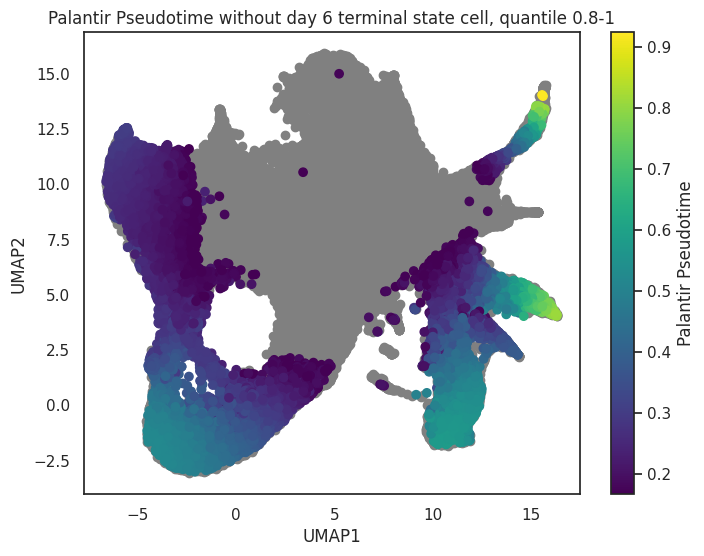

In [15]:
terminal_state = ["Monocyte", "Neutrophil", "Baso", "Mast",
                  "Erythroid", "Meg", "Eos", "Ccr7_DC"]
df = pd.DataFrame({'UMAP1': data.obsm['X_umap'][:, 0], 'UMAP2': data.obsm['X_umap'][:, 1], 
                   'state_info': data.obs['state_info'], 'palantir_pseudotime': data.obs['palantir_pseudotime'],
                   'Time_Point': data.obs['Time_Point']})
df1 = df[(df['Time_Point'] == '6.0' ) & (df['state_info'].isin(terminal_state))]
df2 = df[~df.index.isin(df1.index)]
import numpy as np
# Compute the 20th percentile cutoff
lower_bound = np.quantile(df2['palantir_pseudotime'], 0.8)  # 0th percentile (min value)
upper_bound = np.quantile(df2['palantir_pseudotime'], 1)  # 20th percentile
# Subset data
df2_1 = df2[(df2['palantir_pseudotime'] >= lower_bound) & (df2['palantir_pseudotime'] <= upper_bound)]
df2_2 = df2[~df2.index.isin(df2_1.index)]
plt.figure(figsize=(8, 6))
sc = plt.scatter(df1["UMAP1"], df1["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_2["UMAP1"], df2_2["UMAP2"], c='grey', alpha=1)
sc = plt.scatter(df2_1["UMAP1"], df2_1["UMAP2"], c=df2_1["palantir_pseudotime"], cmap='viridis', alpha=1)
# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Palantir Pseudotime')
# Labels and title
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Palantir Pseudotime without day 6 terminal state cell, quantile 0.8-1')
#plt.savefig('/home/yzhao4/new_repo_branchpoint/Data/Larrydata/Palantir/palantir_pseudotime_without_day6terminal_quant80_100.png', dpi = 300)